# 1.2 Vektoren, Matrizen & Daten — Lösung

Begleit-Notebook zu **Lektion 1.2**. Du implementierst die Grundoperationen der linearen Algebra erst "von Hand" mit Schleifen
und dann vektorisiert mit NumPy – und misst, wie viel schneller das ist.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
rng = np.random.default_rng(42)

## 1. Das Skalarprodukt

**Aufgabe 1.1:** Implementiere das Skalarprodukt mit einer Schleife.

In [2]:
def skalarprodukt(a, b):
    # Summe der paarweisen Produkte mit einer for-Schleife
    summe = 0.0
    for ai, bi in zip(a, b):
        summe += ai * bi
    return summe

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, -1.0, 2.0])
print(skalarprodukt(a, b), a @ b, np.dot(a, b))   # alle drei sollten 8.0 sein

8.0 8.0 8.0


**Aufgabe 1.2:** Implementiere Norm, Winkel und Kosinus-Ähnlichkeit mithilfe von `@`.
Prüfe: Zwei senkrechte Vektoren haben den Winkel 90°.

In [3]:
def norm(v):
    # Länge: Wurzel aus v · v
    return np.sqrt(v @ v)

def kosinus_aehnlichkeit(a, b):
    # (a · b) / (‖a‖ ‖b‖)
    return (a @ b) / (norm(a) * norm(b))

def winkel_grad(a, b):
    return np.degrees(np.arccos(np.clip(kosinus_aehnlichkeit(a, b), -1, 1)))

print(norm(np.array([3.0, 4.0])))                                  # 5.0
print(winkel_grad(np.array([1.0, 0.0]), np.array([0.0, 2.0])))     # 90.0
print(kosinus_aehnlichkeit(np.array([1.0, 1.0]), np.array([2.0, 2.0])))  # 1.0

5.0
90.0
0.9999999999999998


### Anwendung: Ähnliche Dokumente finden

Wir stellen Texte als **Wortzähl-Vektoren** dar (jede Position = ein Wort). Die Kosinus-Ähnlichkeit sagt, welche Texte inhaltlich
ähnlich sind – unabhängig von der Textlänge. Genau so funktionierten frühe Suchmaschinen.

In [4]:
vokabular = ["ball", "tor", "spiel", "zinsen", "bank", "kredit"]
texte = {
    "Fußballbericht":   np.array([3, 4, 2, 0, 0, 0]),
    "Sportkommentar":   np.array([1, 2, 3, 0, 1, 0]),   # "bank" = Ersatzbank :)
    "Wirtschaftsnews":  np.array([0, 0, 0, 3, 2, 4]),
}
anfrage = np.array([1, 1, 0, 0, 0, 0])   # Suche nach "ball tor"

# Kosinus-Ähnlichkeit der Anfrage zu jedem Text ausgeben, sortiert absteigend
for name, v in sorted(texte.items(), key=lambda kv: -kosinus_aehnlichkeit(anfrage, kv[1])):
    print(f"{name:18s} {kosinus_aehnlichkeit(anfrage, v):.3f}")

Fußballbericht     0.919
Sportkommentar     0.548
Wirtschaftsnews    0.000


## 2. Distanzen

**Aufgabe 2.1:** Implementiere euklidische und Manhattan-Distanz **ohne Schleife**. Berechne dann die Distanzmatrix aller Punkte
zueinander mit Broadcasting: `P[:, None, :] - P[None, :, :]` hat die Form `(n, n, d)`.

In [5]:
def euklid(p, q):
    # L2-Distanz
    return np.sqrt(((p - q) ** 2).sum())

def manhattan(p, q):
    # L1-Distanz
    return np.abs(p - q).sum()

p, q = np.array([-2.0, -1.0]), np.array([2.0, 1.5])
print(euklid(p, q), manhattan(p, q))   # 4.717..., 6.5

P = rng.normal(size=(5, 2))
# Distanzmatrix D mit D[i, j] = euklidische Distanz zwischen P[i] und P[j]
D = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(axis=-1))
print(np.round(D, 2))
print("symmetrisch:", np.allclose(D, D.T), " Diagonale 0:", np.allclose(np.diag(D), 0))

4.716990566028302 6.5
[[0.   2.03 2.27 0.75 0.37]
 [2.03 0.   3.51 1.4  1.95]
 [2.27 3.51 0.   2.3  1.99]
 [0.75 1.4  2.3  0.   0.56]
 [0.37 1.95 1.99 0.56 0.  ]]
symmetrisch: True  Diagonale 0: True


### Warum Skalierung wichtig ist

Zwei Wohnungen: Fläche in m² und Zimmerzahl. Welche ist Wohnung A "ähnlicher"?

In [6]:
A = np.array([80.0, 2.0])
B = np.array([82.0, 5.0])    # fast gleiche Fläche, ganz andere Zimmerzahl
C = np.array([95.0, 2.0])    # gleiche Zimmerzahl, etwas größer
print("d(A,B) =", euklid(A, B), "  d(A,C) =", euklid(A, C))

daten = np.array([A, B, C, [60, 1], [120, 4], [70, 3]])
# Standardisiere jede Spalte: (x - Mittelwert) / Standardabweichung (axis=0, Broadcasting!)
Z = (daten - daten.mean(axis=0)) / daten.std(axis=0)
print("standardisiert: d(A,B) =", round(euklid(Z[0], Z[1]), 3), "  d(A,C) =", round(euklid(Z[0], Z[2]), 3))

d(A,B) = 3.605551275463989   d(A,C) = 15.0
standardisiert: d(A,B) = 2.235   d(A,C) = 0.782


Unskaliert dominiert die Fläche. Nach der Standardisierung zählt die Zimmerzahl genauso – das Ergebnis dreht sich um.

## 3. Matrix mal Vektor: ein lineares Modell

Ein lineares Modell sagt für jede Zeile von `X` voraus: $\hat y_i = w \cdot x_i + b$.

**Aufgabe 3.1:** Berechne die Vorhersagen einmal mit Schleife und einmal mit `X @ w + b`. Vergleiche die Laufzeit.

In [7]:
import time

n, d = 200_000, 20
X = rng.normal(size=(n, d))
w = rng.normal(size=d)
b = 0.5

t0 = time.perf_counter()
# Vorhersagen mit einer Schleife über alle Zeilen (nutze deine Funktion skalarprodukt)
y_schleife = np.array([skalarprodukt(x, w) + b for x in X])
t1 = time.perf_counter()
# Vorhersagen vektorisiert
y_vec = X @ w + b
t2 = time.perf_counter()

print(f"Schleife: {t1 - t0:.3f} s   vektorisiert: {t2 - t1:.4f} s   Faktor: {(t1 - t0) / (t2 - t1):.0f}x")
print("gleiches Ergebnis:", np.allclose(y_schleife, y_vec))

Schleife: 0.997 s   vektorisiert: 0.0019 s   Faktor: 522x
gleiches Ergebnis: True


## 4. Matrizen als Abbildungen

Wir wenden verschiedene 2×2-Matrizen auf ein Gitter von Punkten an. **Aufgabe 4.1:** Ergänze die Drehmatrix für einen Winkel θ:

$$R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

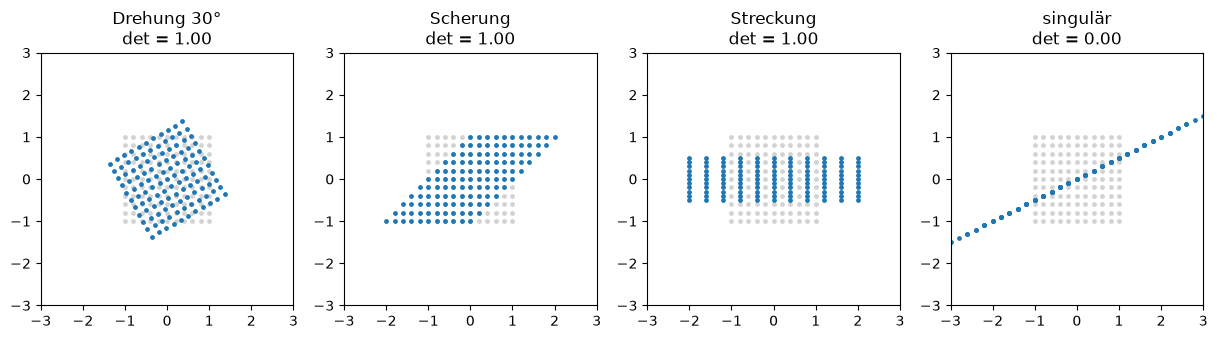

In [8]:
def drehung(theta):
    # 2x2-Drehmatrix
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

gx, gy = np.meshgrid(np.linspace(-1, 1, 11), np.linspace(-1, 1, 11))
punkte = np.stack([gx.ravel(), gy.ravel()])        # Form (2, 121): Punkte als Spalten

matrizen = {"Drehung 30°": drehung(np.pi / 6), "Scherung": np.array([[1, 1], [0, 1]]),
            "Streckung": np.array([[2, 0], [0, 0.5]]), "singulär": np.array([[1, 2], [0.5, 1]])}
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, M) in zip(axes, matrizen.items()):
    neu = M @ punkte
    ax.scatter(*punkte, s=6, c="lightgray")
    ax.scatter(*neu, s=6)
    ax.set_title(f"{name}\ndet = {np.linalg.det(M):.2f}")
    ax.set_aspect("equal"); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.show()

**Aufgabe 4.2:** Prüfe numerisch: Eine Drehung ändert keine Längen (Determinante 1), und $R(\theta)^{-1} = R(-\theta) = R(\theta)^\top$.

In [9]:
R = drehung(0.7)
v = np.array([3.0, 4.0])
# Länge von v vor und nach der Drehung vergleichen, Inverse mit Transponierter vergleichen
print(norm(v), norm(R @ v))
print(np.allclose(np.linalg.inv(R), R.T), np.allclose(R.T, drehung(-0.7)))

5.0 5.0
True True


## 5. Ausblick: die Normalengleichung

Für lineare Regression gibt es die geschlossene Lösung $w^* = (X^\top X)^{-1} X^\top y$. Wir erzeugen Daten mit bekannten Gewichten
und prüfen, ob die Formel sie wiederfindet. (Der Bias wird über eine Spalte aus Einsen modelliert.)

In [10]:
n = 500
X = rng.normal(size=(n, 3))
w_wahr = np.array([2.0, -1.0, 0.5])
y = X @ w_wahr + 3.0 + rng.normal(scale=0.1, size=n)

X1 = np.c_[np.ones(n), X]          # Spalte mit Einsen für den Bias
# Normalengleichung (Tipp: np.linalg.solve(A, c) löst A x = c stabiler als inv)
w_hat = np.linalg.solve(X1.T @ X1, X1.T @ y)
print("geschätzt:", np.round(w_hat, 3), "  wahr: [3. 2. -1. 0.5]")

geschätzt: [ 3.001  1.992 -0.991  0.496]   wahr: [3. 2. -1. 0.5]
